In [23]:

from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from dotenv import load_dotenv
from langchain_core.tools import tool
from langgraph.checkpoint.postgres import PostgresSaver
import os   

load_dotenv(override=True)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
model = ChatGroq(model="openai/gpt-oss-120b")


In [24]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages" : [response]}

In [25]:
builder = StateGraph(MessagesState)
builder.add_node("call_model",call_model)
builder.add_edge(START,"call_model")

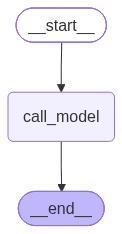

In [26]:
graph = builder.compile()
graph

In [27]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
config = {"configurable" : {"thread_id" : "thread-1"}}
graph.invoke({"messages":[{"role" : "user" , "content" : "Hi My Name is vijay"}]}, config)


{'messages': [HumanMessage(content='Hi My Name is vijay', additional_kwargs={}, response_metadata={}, id='13d13bee-4aaf-49a8-953c-e48beceb38cb'),
  AIMessage(content='Hello Vijay! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi My Name is vijay". Likely they want a response. We can greet them. No disallowed content. We can respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 77, 'total_tokens': 135, 'completion_time': 0.123088857, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.002856857, 'prompt_tokens_details': None, 'queue_time': 0.28152641, 'total_time': 0.125945714}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5082008e34', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0421f-83b6-7660-845a-846c2d7c0cd1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens

In [29]:
graph.invoke({"messages":[{"role" : "user" , "content" : "what is my name ?"}]}, config)


{'messages': [HumanMessage(content='Hi My Name is vijay', additional_kwargs={}, response_metadata={}, id='13d13bee-4aaf-49a8-953c-e48beceb38cb'),
  AIMessage(content='Hello Vijay! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi My Name is vijay". Likely they want a response. We can greet them. No disallowed content. We can respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 77, 'total_tokens': 135, 'completion_time': 0.123088857, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.002856857, 'prompt_tokens_details': None, 'queue_time': 0.28152641, 'total_time': 0.125945714}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5082008e34', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0421f-83b6-7660-845a-846c2d7c0cd1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens

In [ ]:
snap = graph.get_state(config)
vals= snap.values
for m in vals.gyet("messages",[]):
    print("_", type(m).__name__, ":",m.content)

_ HumanMessage : Hi My Name is vijay
_ AIMessage : Hello Vijay! Nice to meet you. How can I help you today?
_ HumanMessage : what is my name ?
_ AIMessage : Your name is Vijay.
